In [1]:
%pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
import imblearn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')
import joblib

In [3]:
df = pd.read_csv('D:\CreditCardFraud_LogisticRegression_MLModel\creditcard_fraud_cleaned.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_train_scaled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
225399,1.045499,1.147198,-1.042032,-1.428821,-1.817824,0.727198,2.695677,-1.489310,0.735746,-1.152704,...,-0.427196,-0.208573,-0.068205,0.445379,1.130202,-0.420363,-0.331281,0.092782,-0.156193,-0.229434
133746,-0.298690,-0.677911,0.991948,0.394668,-0.025642,-0.301198,-0.728240,0.175615,0.629070,-1.156290,...,-0.089833,-0.332248,-1.307141,0.518036,0.851069,-1.367338,-0.554255,-0.049864,0.153831,-0.331197
185792,0.678397,0.977654,0.016205,-1.386701,0.092688,0.850613,0.458823,-0.019872,0.154370,0.262056,...,-0.277973,0.405040,1.512732,-0.071350,-2.788905,0.202924,0.015479,0.111329,-0.165820,-0.298809
148925,-0.074929,0.927561,0.195261,0.208736,2.739855,0.032003,0.772348,-0.613532,0.199999,0.625478,...,-0.301091,0.190793,0.966846,0.278559,1.160348,-0.407893,-0.021447,-0.049724,-0.119582,-0.289247
18398,-1.376728,0.695218,-0.676118,0.363661,-1.090812,-0.882507,0.209618,-1.002620,0.182243,-1.911610,...,-0.477066,-0.473576,-0.878722,0.404329,-0.568164,-0.123705,-0.913882,0.155776,0.037290,-0.261985


In [7]:
X_test_scaled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
86249,-0.707761,0.628460,-0.035074,0.180468,0.458370,-0.039036,0.282631,-0.188064,0.068546,0.588310,...,-0.127997,-0.180855,-0.115760,-0.242019,-1.156152,1.146985,1.020188,0.003348,0.002563,-0.312846
250634,1.273872,-0.106908,0.716669,-0.505369,-0.364476,0.459466,-0.543838,0.531099,0.208316,-0.141314,...,-0.130450,0.531063,1.665848,-0.131889,0.839109,-1.363325,-0.487793,0.967692,0.799400,-0.351745
20163,-1.348111,-0.861641,0.852834,0.996379,1.536755,0.511055,0.804066,0.927266,-0.458042,-0.228599,...,1.089947,-0.729689,-0.564378,-0.447264,-1.397309,-0.298492,-0.130228,0.015608,0.346748,0.011771
68688,-0.878056,0.418198,-0.678562,0.340281,0.364139,-0.745777,0.370595,-0.485054,0.160690,-0.910613,...,-0.145875,-0.080683,-0.232112,-0.317248,-0.557019,0.456819,-0.601931,0.093533,0.176391,0.568071
191151,0.727104,1.029469,0.067400,-1.164286,0.416623,0.272028,-0.480523,0.006482,-0.110551,0.452905,...,-0.179232,0.010940,0.493289,-0.021163,-0.737787,0.213322,1.334977,-0.099032,-0.136154,-0.353901


In [9]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_naive= model.predict(X_test_scaled)
y_prob_naive= model.predict_proba(X_test_scaled)[:, 1]

In [10]:
threshold = 0.5
predictions = []
for i in model.predict_proba(X_test_scaled):
    if i[1] >= threshold:
        predictions.append(1)
    else:
        predictions.append(0)
print(predictions)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [11]:
acc = accuracy_score(y_test, y_pred_naive)
prec = precision_score(y_test, y_pred_naive)
rec = recall_score(y_test, y_pred_naive)
f1 = f1_score(y_test, y_pred_naive)
roc_auc = roc_auc_score(y_test, y_prob_naive)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.9991
Precision: 0.8462
Recall: 0.5789
F1 Score: 0.6875
ROC AUC: 0.9560


In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_naive)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"                    Predicted")
print(f"                  Legit    Fraud")
print(f"  Actual Legit  [{tn:>6,}   {fp:>5,}]")
print(f"  Actual Fraud  [{fn:>6,}   {tp:>5,}]")

print(f"\n--- What This Means ---")
print(f"  True Negatives:  {tn:,} legit transactions correctly identified")
print(f"  False Positives: {fp:,} legit transactions wrongly flagged as fraud")
print(f"  True Positives:  {tp:,} frauds correctly caught ✅")
print(f"  False Negatives: {fn:,} FRAUDS MISSED! ❌")
print(f"\n  >>> The model MISSED {fn} out of {fn+tp} frauds ({fn/(fn+tp)*100:.1f}%) <<<")
print(f"  >>> The bank loses money on {fn} undetected fraudulent transactions! <<<")


Confusion Matrix:
                    Predicted
                  Legit    Fraud
  Actual Legit  [56,641      10]
  Actual Fraud  [    40      55]

--- What This Means ---
  True Negatives:  56,641 legit transactions correctly identified
  False Positives: 10 legit transactions wrongly flagged as fraud
  True Positives:  55 frauds correctly caught ✅
  False Negatives: 40 FRAUDS MISSED! ❌

  >>> The model MISSED 40 out of 95 frauds (42.1%) <<<
  >>> The bank loses money on 40 undetected fraudulent transactions! <<<


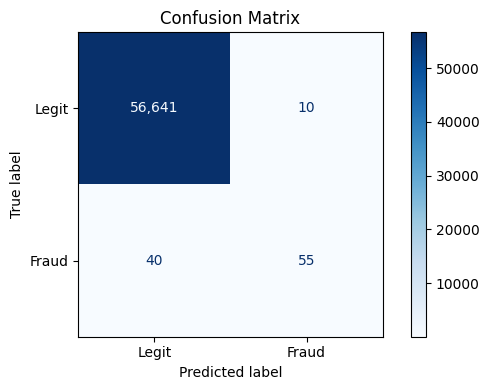

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_naive, display_labels=['Legit', 'Fraud'], cmap='Blues', ax=ax, values_format=',')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [14]:
print(classification_report(y_test, y_pred_naive, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [15]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
y_pred_dummy

array([0, 0, 0, ..., 0, 0, 0], shape=(56746,))

Class Weights

In [16]:
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)
y_pred_bal = lr_balanced.predict(X_test_scaled)
y_prob_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]
cm_bal = confusion_matrix(y_test, y_pred_bal)
tn_bal, fp_bal, fn_bal, tp_bal = cm_bal.ravel()

In [17]:
print("=" * 60)
print("FIX #1: class_weight='balanced'")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_bal):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_bal):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_bal):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_bal):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_bal):.4f}")
print(f"\n  Frauds caught: {tp_bal} out of {tp_bal+fn_bal} ({tp_bal/(tp_bal+fn_bal)*100:.1f}%)")
print(f"  Frauds missed: {fn_bal} ({fn_bal/(tp_bal+fn_bal)*100:.1f}%)")
print(f"  False alarms:  {fp_bal} legit transactions wrongly flagged")

FIX #1: class_weight='balanced'
  Accuracy:  0.9753
  Precision: 0.0564
  Recall:    0.8737
  F1-Score:  0.1059
  ROC-AUC:   0.9657

  Frauds caught: 83 out of 95 (87.4%)
  Frauds missed: 12 (12.6%)
  False alarms:  1389 legit transactions wrongly flagged


Under Sampling

In [19]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

In [21]:
lr_under = LogisticRegression(max_iter=1000, random_state=42)
lr_under.fit(X_train_under, y_train_under)
y_pred_under = lr_under.predict(X_test_scaled)
y_prob_under = lr_under.predict_proba(X_test_scaled)[:, 1]
cm_under = confusion_matrix(y_test, y_pred_under)
tn_under, fp_under, fn_under, tp_under = cm_under.ravel()
print("=" * 60)
print("FIX #2: Random Undersampling")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_under):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_under):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_under):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_under):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_under):.4f}")
print(f"\n  Frauds caught: {tp_under} out of {tp_under+fn_under} ({tp_under/(tp_under+fn_under)*100:.1f}%)")
print(f"  Frauds missed: {fn_under}")
print(f"  False alarms:  {fp_under:,} legit transactions wrongly flagged")

FIX #2: Random Undersampling
  Accuracy:  0.9722
  Precision: 0.0504
  Recall:    0.8737
  F1-Score:  0.0953
  ROC-AUC:   0.9571

  Frauds caught: 83 out of 95 (87.4%)
  Frauds missed: 12
  False alarms:  1,563 legit transactions wrongly flagged


Over Sampling

In [43]:
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_test_scaled)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]
cm = confusion_matrix(y_test, y_pred_smote)
tn_smote, fp_smote, fn_smote, tp_smote = cm.ravel()

In [44]:
print("=" * 60)
print("FIX #3: SMOTE (Full Oversampling)")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_smote):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_smote):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_smote):.4f}")
print(f"\n  Frauds caught: {tp_smote} out of {tp_smote+fn_smote} ({tp_smote/(tp_smote+fn_smote)*100:.1f}%)")
print(f"  Frauds missed: {fn_smote}")
print(f"  False alarms:  {fp_smote:,}")

FIX #3: SMOTE (Full Oversampling)
  Accuracy:  0.9977
  Precision: 0.4000
  Recall:    0.8000
  F1-Score:  0.5333
  ROC-AUC:   0.9664

  Frauds caught: 76 out of 95 (80.0%)
  Frauds missed: 19
  False alarms:  114


In [45]:
print(f"{'Method':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Missed':>8}")
print("-" * 75)

results = [
    ("Naive LogReg", y_pred_naive, y_prob_naive, fn),
    ("class_weight='balanced'", y_pred_bal, y_prob_bal, fn_bal),
    ("Undersampling", y_pred_under, y_prob_under, fn_under),
    ("SMOTE (full)", y_pred_smote, y_prob_smote, fn_smote),
]

for name, y_p, y_pr, missed in results:
    print(f"{name:<28} {accuracy_score(y_test, y_p):>9.4f} "
          f"{precision_score(y_test, y_p):>10.4f} "
          f"{recall_score(y_test, y_p):>8.4f} "
          f"{f1_score(y_test, y_p):>8.4f} "
          f"{missed:>8}")

Method                        Accuracy  Precision   Recall       F1   Missed
---------------------------------------------------------------------------
Naive LogReg                    0.9991     0.8462   0.5789   0.6875       40
class_weight='balanced'         0.9753     0.0564   0.8737   0.1059       12
Undersampling                   0.9722     0.0504   0.8737   0.0953       12
SMOTE (full)                    0.9977     0.4000   0.8000   0.5333       19


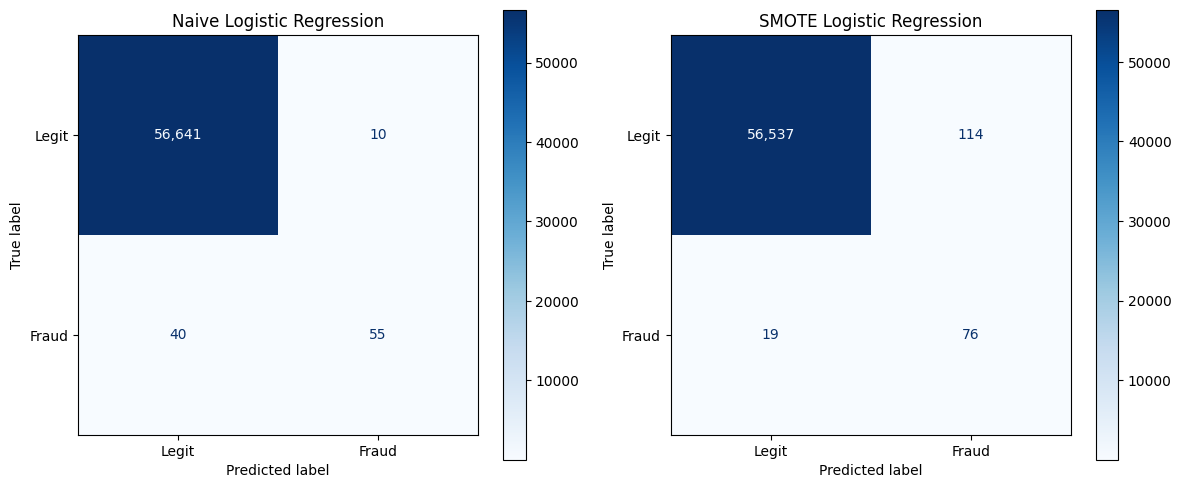

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_naive, display_labels=['Legit', 'Fraud'], cmap='Blues', ax=axes[0], values_format=',')
axes[0].set_title('Naive Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, display_labels=['Legit', 'Fraud'], cmap='Blues', ax=axes[1], values_format=',')
axes[1].set_title('SMOTE Logistic Regression')
plt.tight_layout()
plt.show()

In [48]:
fpr_smote, tpr_smote, thresholds_smote = roc_curve(y_test, y_prob_smote)
print(tpr_smote)
print("="*60)
print(fpr_smote)
print("="*60)
print(thresholds_smote)

[0.         0.03157895 0.07368421 0.07368421 0.12631579 0.12631579
 0.14736842 0.14736842 0.16842105 0.16842105 0.17894737 0.17894737
 0.35789474 0.35789474 0.37894737 0.37894737 0.68421053 0.68421053
 0.69473684 0.69473684 0.70526316 0.70526316 0.71578947 0.71578947
 0.73684211 0.73684211 0.76842105 0.76842105 0.77894737 0.77894737
 0.78947368 0.78947368 0.8        0.8        0.81052632 0.81052632
 0.82105263 0.82105263 0.83157895 0.83157895 0.84210526 0.84210526
 0.85263158 0.85263158 0.86315789 0.86315789 0.87368421 0.87368421
 0.88421053 0.88421053 0.89473684 0.89473684 0.90526316 0.90526316
 0.91578947 0.91578947 0.92631579 0.92631579 0.93684211 0.93684211
 0.94736842 0.94736842 0.95789474 0.95789474 0.96842105 0.96842105
 0.97894737 0.97894737 0.98947368 0.98947368 1.         1.        ]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.76519391e-05
 1.76519391e-05 3.53038781e-05 3.53038781e-05 7.06077563e-05
 7.06077563e-05 8.82596953e-05 8.82596953e-05 1.23563573e-04
 1.23563573e

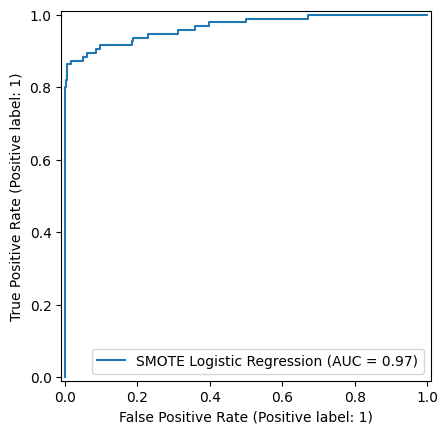

In [50]:
RocCurveDisplay.from_predictions(y_test, y_prob_smote, name='SMOTE Logistic Regression')
plt.show()

In [51]:
thresholds = np.arange(0.05, 0.96, 0.05)

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'FP':>8} {'FN':>8}")
print("-" * 60)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    y_pred_t = (y_prob_smote >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    if f > best_f1:
        best_f1 = f
        best_thresh = t

    print(f"{t:>10.2f} {p:>10.4f} {r:>10.4f} {f:>10.4f} {fp:>8,} {fn:>8}")

print(f"\nBest F1 threshold: {best_thresh:.2f} (F1 = {best_f1:.4f})")


 Threshold  Precision     Recall         F1       FP       FN
------------------------------------------------------------
      0.05     0.0316     0.8737     0.0609    2,547       12
      0.10     0.0754     0.8737     0.1388    1,018       12
      0.15     0.1254     0.8632     0.2190      572       13
      0.20     0.1673     0.8632     0.2803      408       13
      0.25     0.1914     0.8421     0.3119      338       15
      0.30     0.2194     0.8316     0.3473      281       16
      0.35     0.2461     0.8211     0.3786      239       17
      0.40     0.2921     0.8211     0.4309      189       17
      0.45     0.3406     0.8211     0.4815      151       17
      0.50     0.4000     0.8000     0.5333      114       19
      0.55     0.4935     0.8000     0.6104       78       19
      0.60     0.5474     0.7895     0.6466       62       20
      0.65     0.6048     0.7895     0.6849       49       20
      0.70     0.6637     0.7895     0.7212       38       20
      0.7

In [55]:
lr_th = LogisticRegression(max_iter=1000, random_state=42)
lr_th.fit(X_train_smote, y_train_smote)
y_prob_th = lr_th.predict_proba(X_test_scaled)[:, 1]
y_pred_th = (y_prob_th >= best_thresh).astype(int)
cm_th = confusion_matrix(y_test, y_pred_th)
tn_th, fp_th, fn_th, tp_th = cm_th.ravel()

In [57]:
print("=" * 60)
print("Threshold 0.95")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_th):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_th):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_th):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_th):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_th):.4f}")
print(f"\n  Frauds caught: {tp_th} out of {tp_th+fn_th} ({tp_th/(tp_th+fn_th)*100:.1f}%)")
print(f"  Frauds missed: {fn_th}")
print(f"  False alarms:  {fp_th:,}")

Threshold 0.95
  Accuracy:  0.9993
  Precision: 0.8295
  Recall:    0.7684
  F1-Score:  0.7978
  ROC-AUC:   0.9664

  Frauds caught: 73 out of 95 (76.8%)
  Frauds missed: 22
  False alarms:  15


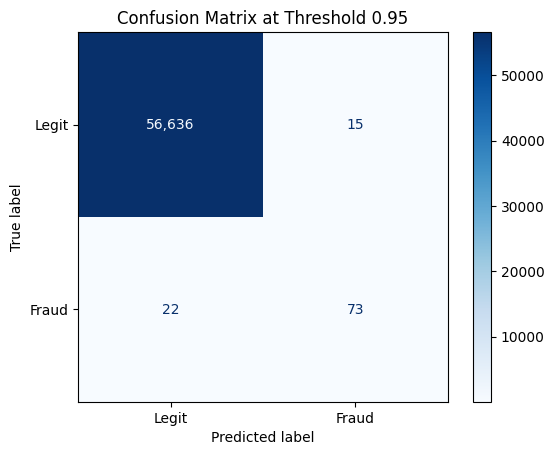

In [58]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_th, display_labels=['Legit', 'Fraud'], cmap='Blues', values_format=',')
plt.title('Confusion Matrix at Threshold 0.95')
plt.show()

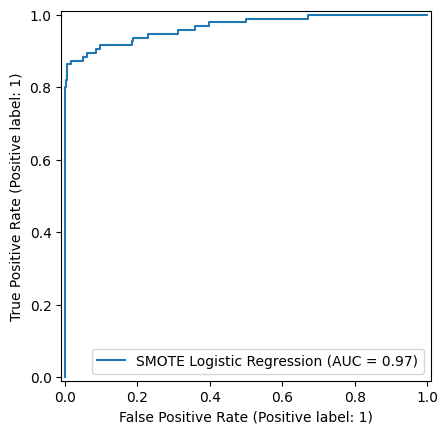

In [56]:
RocCurveDisplay.from_predictions(y_test, y_prob_th, name='SMOTE Logistic Regression')
plt.show()

In [59]:
print(f"{'Method':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Missed':>8}")
print("-" * 75)

results = [
    ("Naive LogReg", y_pred_naive, y_prob_naive, fn),
    ("class_weight='balanced'", y_pred_bal, y_prob_bal, fn_bal),
    ("Undersampling", y_pred_under, y_prob_under, fn_under),
    ("SMOTE (full)", y_pred_smote, y_prob_smote, fn_smote),
    ("SMOTE + Thresh", y_pred_th, y_prob_th, fn_th),
]

for name, y_p, y_pr, missed in results:
    print(f"{name:<28} {accuracy_score(y_test, y_p):>9.4f} "
          f"{precision_score(y_test, y_p):>10.4f} "
          f"{recall_score(y_test, y_p):>8.4f} "
          f"{f1_score(y_test, y_p):>8.4f} "
          f"{missed:>8}")

Method                        Accuracy  Precision   Recall       F1   Missed
---------------------------------------------------------------------------
Naive LogReg                    0.9991     0.8462   0.5789   0.6875       22
class_weight='balanced'         0.9753     0.0564   0.8737   0.1059       12
Undersampling                   0.9722     0.0504   0.8737   0.0953       12
SMOTE (full)                    0.9977     0.4000   0.8000   0.5333       19
SMOTE + Thresh                  0.9993     0.8295   0.7684   0.7978       22
